## Synthetic CMAB experiments

This notebook runs the synthetic part of the thesis using a regime-specific comparison:

| Synthetic environment | Baseline | Fair variant |
|---|---|---|
| deterministic | `LinUCB` | `FairLinUCB_DP` |
| stochastic | `LinTS` | `FairLinTS_DP` |
| adversarial  | `EXP4` | `FairEXP4_DP` |

The goal is to avoid comparing algorithms outside their intended assumptions. This notebook is therefore the main synthetic benchmark notebook.


### Imports and package check

In [ ]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from fair_bandits.config import build_config
from fair_bandits.data.synthetic import (
    make_synthetic_cmab_dataset,
    make_synthetic_expert_advice,
    quick_synthetic_diagnostics,
)
from fair_bandits.experiments import (
    run_regime_matched_synth_benchmark,
    make_synth_temporal_ci,
    make_synth_summary_table,
    compare_methods,
)
from fair_bandits.plots import plot_synth_temporal_metric

### Configuration

In [2]:
RUN_MODE = "full"  # change to "full" for final results

CFG = build_config(RUN_MODE)

SYNTHETIC_ROOT = CFG.results_dir / "synthetic_cmab_regime_matched"
SYNTHETIC_ROOT.mkdir(parents=True, exist_ok=True)

if RUN_MODE == "dev":
    HORIZONS = (100, 250)
    SEEDS = tuple(range(3))
else:
    HORIZONS = (50, 100, 250, 500)
    SEEDS = tuple(range(CFG.n_seeds))

D = 10
N_EXPERTS = 6

RUN_DIR = SYNTHETIC_ROOT / RUN_MODE
RUN_DIR.mkdir(parents=True, exist_ok=True)

print("Run mode:", RUN_MODE)
print("Horizons:", HORIZONS)
print("Seeds:", SEEDS)
print("Output directory:", RUN_DIR)
CFG

Run mode: full
Horizons: (50, 100, 250, 500)
Seeds: (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49)
Output directory: results\full\synthetic_cmab_regime_matched\full


ExperimentConfig(run_mode='full', seed0=42, cache_dir=WindowsPath('data_cache'), results_dir=WindowsPath('results/full'), T_group_bandit=50000, T_contextual=30000, n_seeds=50, delta_fair=0.05, alpha_linucb=1.5, lambda_ridge=1.0, dp_tau=0.02, dp_lambda=2.0, beta_smooth=1.0, min_group_count=20, compas_hash_features=512, n_bootstrap=1000)

### Sanity check: one synthetic environment

Checks that the generator produces a reasonable synthetic CMAB dataset and that expert advice has the expected shape for EXP4.

Dataframe head:


,t,group,oracle_action,oracle_prob,p_action_0,p_action_1
0,0,1,1,0.822496,0.122014,0.822496
1,1,1,1,0.853414,0.249726,0.853414
2,2,1,1,0.870431,0.202195,0.870431
3,3,1,1,0.824719,0.211172,0.824719
4,4,1,1,0.903161,0.256031,0.903161


X shape: (500, 10)
Group shape: (500,)
Oracle action shape: (500,)
Expert advice shape: (500, 6, 2)
Expert names: ['oracle_like', 'noisy_oracle', 'group0_positive_bias', 'group1_positive_bias', 'conservative_action0', 'random']
Config:
{'T': 500, 'd': 10, 'n_actions': 2, 'group_prob': 0.5, 'regime': 'adversarial_switching', 'reward_noise_std': 0.1, 'theta_scale': 1.0, 'bias_action1_group0': 0.45, 'bias_action1_group1': 0.15, 'bias_action0_group0': 0.0, 'bias_action0_group1': 0.0, 'context_mean_shift_group1': 0.0, 'clip_logits': 4.0, 'adversarial_block_size': 50, 'adversarial_shock_scale': 1.5, 'adversarial_flip_odd_blocks': True}

Group counts:
group
0    261
1    239
Name: count, dtype: int64

Oracle action distribution:
oracle_action
0    250
1    250
Name: count, dtype: int64

Mean oracle probability: 0.8307



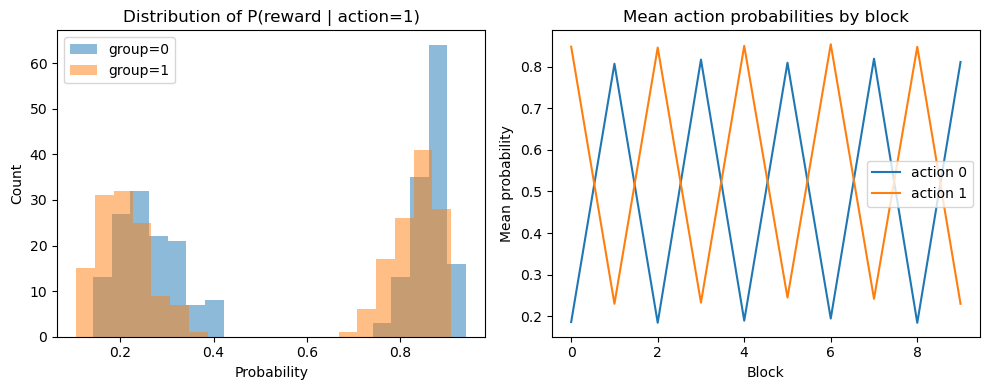

In [3]:
sanity = make_synthetic_cmab_dataset(
    T=500,
    d=D,
    regime="adversarial_switching",
    seed=42,
)

print("Dataframe head:")
display(sanity["df"].head())

print("X shape:", sanity["X"].shape)
print("Group shape:", sanity["group"].shape)
print("Oracle action shape:", sanity["y_opt"].shape)

expert_advice, expert_names = make_synthetic_expert_advice(
    sanity,
    n_experts=N_EXPERTS,
    seed=42,
)

print("Expert advice shape:", expert_advice.shape)
print("Expert names:", expert_names)

quick_synthetic_diagnostics(sanity)

### Run or load the regime-matched synthetic benchmark

The benchmark uses the following mapping:

- `stationary_deterministic`: `LinUCB` vs `FairLinUCB_DP`
- `stationary_stochastic`: `LinTS` vs `FairLinTS_DP`
- `adversarial_switching`: `EXP4` vs `FairEXP4_DP`


In [4]:
PERSEED_PATH = RUN_DIR / "perseed.csv"
CI_LONG_PATH = RUN_DIR / "ci_long.csv"
LOGS_PATH = RUN_DIR / "logs.csv"
TEMPORAL_PATH = RUN_DIR / "temporal_ci.csv"
SUMMARY_500_PATH = RUN_DIR / "summary_table_T500.csv"
METADATA_PATH = RUN_DIR / "metadata.json"

FORCE_RERUN = False

if (
    not FORCE_RERUN
    and PERSEED_PATH.exists()
    and CI_LONG_PATH.exists()
    and LOGS_PATH.exists()
    and TEMPORAL_PATH.exists()
):
    perseed = pd.read_csv(PERSEED_PATH)
    ci_long = pd.read_csv(CI_LONG_PATH)
    logs = pd.read_csv(LOGS_PATH)
    temporal_ci = pd.read_csv(TEMPORAL_PATH)
    print("Loaded cached synthetic benchmark from:", RUN_DIR)
else:
    results = run_regime_matched_synth_benchmark(
        horizons=HORIZONS,
        seeds=SEEDS,
        d=D,
        dataset_overrides={},
        alpha_linucb=CFG.alpha_linucb,
        lambda_ridge=CFG.lambda_ridge,
        ts_v=0.5,
        exp4_gamma=0.07,
        dp_tau=CFG.dp_tau,
        dp_lambda_lin=CFG.dp_lambda,
        dp_lambda_exp4=0.20,
        beta_smooth=CFG.beta_smooth,
        min_group_count=CFG.min_group_count,
        n_experts=N_EXPERTS,
        keep_logs=True,
    )

    perseed = results["perseed"]
    ci_long = results["ci_long"]
    logs = results["logs"]
    temporal_ci = make_synth_temporal_ci(logs)

    perseed.to_csv(PERSEED_PATH, index=False)
    ci_long.to_csv(CI_LONG_PATH, index=False)
    logs.to_csv(LOGS_PATH, index=False)
    temporal_ci.to_csv(TEMPORAL_PATH, index=False)

    metadata = {
        "run_mode": RUN_MODE,
        "horizons": list(HORIZONS),
        "seeds": list(SEEDS),
        "d": D,
        "n_experts": N_EXPERTS,
        "alpha_linucb": CFG.alpha_linucb,
        "lambda_ridge": CFG.lambda_ridge,
        "ts_v": 0.5,
        "exp4_gamma": 0.07,
        "dp_tau": CFG.dp_tau,
        "dp_lambda_lin": CFG.dp_lambda,
        "dp_lambda_exp4": 0.20,
        "beta_smooth": CFG.beta_smooth,
        "min_group_count": CFG.min_group_count,
    }
    with open(METADATA_PATH, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=2)

    print("Saved synthetic benchmark to:", RUN_DIR)

print("perseed:", perseed.shape)
print("ci_long:", ci_long.shape)
print("logs:", logs.shape)
print("temporal_ci:", temporal_ci.shape)

Loaded cached synthetic benchmark from: results\full\synthetic_cmab_regime_matched\full
perseed: (240, 16)
ci_long: (264, 8)
logs: (54000, 19)
temporal_ci: (21600, 9)


### Inspect outputs

In [5]:
display(perseed.head())
display(ci_long.head())
display(temporal_ci.head())

print("Regimes:", sorted(perseed["regime"].unique().tolist()))
print("Policies:", sorted(perseed["policy"].unique().tolist()))
print("Horizons:", sorted(perseed["T"].unique().tolist()))

,accuracy,DP_gap,TPR_gap,FPR_gap,EO_gap,PPV_gap,UtilityGap,CumulativeRegret,avg_reward,cumulative_regret,final_DP_gap_over_time,policy,regime,T,seed,algorithm_family
0,0.56,0.405844,0.484848,0.323864,0.484848,0.118056,0.094156,12.0,0.72,12.0,0.405844,LinUCB,stationary_deterministic,50,0,UCB
1,0.48,0.253247,0.393939,0.136364,0.393939,0.200000,0.084416,14.0,0.68,14.0,0.253247,FairLinUCB_DP,stationary_deterministic,50,0,UCB
2,0.74,0.090909,0.013072,0.370629,0.370629,0.390110,0.048701,8.0,0.80,8.0,0.090909,LinUCB,stationary_deterministic,50,1,UCB
3,0.74,0.090909,0.013072,0.370629,0.370629,0.390110,0.048701,8.0,0.80,8.0,0.090909,FairLinUCB_DP,stationary_deterministic,50,1,UCB
4,0.60,0.240385,0.500000,0.273810,0.500000,0.354167,0.128205,6.0,0.60,6.0,0.240385,LinUCB,stationary_deterministic,50,2,UCB


,regime,T,policy,metric,mean,ci_low,ci_high,n_seeds
0,adversarial_switching,50,EXP4,accuracy,0.772000,0.724500,0.815500,10
1,adversarial_switching,50,EXP4,DP_gap,0.095649,0.013374,0.221639,10
2,adversarial_switching,50,EXP4,TPR_gap,0.095649,0.013374,0.221639,10
3,adversarial_switching,50,EXP4,FPR_gap,0.000000,0.000000,0.000000,10
4,adversarial_switching,50,EXP4,EO_gap,0.095649,0.013374,0.221639,10


,regime,T,policy,t,metric,mean,ci_low,ci_high,n_seeds
0,adversarial_switching,50,EXP4,1,DP_gap,0.90,0.225,1.000000,10
1,adversarial_switching,50,EXP4,2,DP_gap,0.45,0.000,1.000000,10
2,adversarial_switching,50,EXP4,3,DP_gap,0.25,0.000,0.887500,10
3,adversarial_switching,50,EXP4,4,DP_gap,0.35,0.000,0.666667,10
4,adversarial_switching,50,EXP4,5,DP_gap,0.35,0.000,0.666667,10


Regimes: ['adversarial_switching', 'stationary_deterministic', 'stationary_stochastic']
Policies: ['EXP4', 'FairEXP4_DP', 'FairLinTS_DP', 'FairLinUCB_DP', 'LinTS', 'LinUCB']
Horizons: [50, 100, 250, 500]


### Final summary table

The main thesis table should usually report the largest horizon. In `dev` mode the largest horizon is not necessarily 500, so we select the maximum available horizon automatically.


In [6]:
FINAL_T = int(max(perseed["T"].unique()))

summary_table = make_synth_summary_table(ci_long, T=FINAL_T)
display(summary_table)

summary_table.to_csv(RUN_DIR / f"summary_table_T{FINAL_T}.csv", index=False)
print("Saved:", RUN_DIR / f"summary_table_T{FINAL_T}.csv")

metric,regime,policy,DP_gap,EO_gap,PPV_gap,UtilityGap,accuracy,avg_reward,cumulative_regret
0,adversarial_switching,EXP4,0.044 ± 0.046,0.084 ± 0.080,0.066 ± 0.063,0.029 ± 0.057,0.731 ± 0.024,0.669 ± 0.020,81.563 ± 8.726
1,adversarial_switching,FairEXP4_DP,0.039 ± 0.045,0.076 ± 0.082,0.067 ± 0.065,0.027 ± 0.031,0.732 ± 0.023,0.664 ± 0.027,81.463 ± 8.674
2,stationary_deterministic,FairLinUCB_DP,0.023 ± 0.031,0.120 ± 0.034,0.176 ± 0.083,0.081 ± 0.058,0.716 ± 0.048,0.786 ± 0.047,44.800 ± 21.275
3,stationary_deterministic,LinUCB,0.033 ± 0.035,0.134 ± 0.049,0.183 ± 0.089,0.077 ± 0.061,0.722 ± 0.033,0.790 ± 0.046,43.000 ± 13.000
4,stationary_stochastic,FairLinTS_DP,0.031 ± 0.027,0.084 ± 0.141,0.208 ± 0.057,0.052 ± 0.056,0.507 ± 0.144,0.537 ± 0.051,25.056 ± 10.245
5,stationary_stochastic,LinTS,0.028 ± 0.046,0.090 ± 0.075,0.189 ± 0.062,0.078 ± 0.063,0.557 ± 0.095,0.534 ± 0.032,21.166 ± 9.571


Saved: results\full\synthetic_cmab_regime_matched\full\summary_table_T500.csv


### Regime-specific endpoint table

This table is easier to read than the long CI table because it keeps only the metrics most likely to appear in the thesis.


In [7]:
METRICS_KEEP = [
    "accuracy",
    "avg_reward",
    "cumulative_regret",
    "DP_gap",
    "EO_gap",
    "PPV_gap",
    "UtilityGap",
]

endpoint = ci_long[
    (ci_long["T"] == FINAL_T)
    & (ci_long["metric"].isin(METRICS_KEEP))
].copy()

endpoint["mean_ci"] = endpoint.apply(
    lambda r: f"{r['mean']:.3f} [{r['ci_low']:.3f}, {r['ci_high']:.3f}]",
    axis=1,
)

endpoint_table = endpoint.pivot_table(
    index=["regime", "policy"],
    columns="metric",
    values="mean_ci",
    aggfunc="first",
).reset_index()

display(endpoint_table)
endpoint_table.to_csv(RUN_DIR / f"endpoint_table_T{FINAL_T}.csv", index=False)

metric,regime,policy,DP_gap,EO_gap,PPV_gap,UtilityGap,accuracy,avg_reward,cumulative_regret
0,adversarial_switching,EXP4,"0.044 [0.010, 0.090]","0.084 [0.039, 0.165]","0.066 [0.025, 0.129]","0.029 [0.012, 0.085]","0.731 [0.709, 0.755]","0.669 [0.647, 0.689]","81.563 [72.822, 90.289]"
1,adversarial_switching,FairEXP4_DP,"0.039 [0.015, 0.084]","0.076 [0.028, 0.157]","0.067 [0.018, 0.132]","0.027 [0.004, 0.059]","0.732 [0.710, 0.755]","0.664 [0.633, 0.692]","81.463 [72.840, 90.137]"
2,stationary_deterministic,FairLinUCB_DP,"0.023 [0.006, 0.054]","0.120 [0.083, 0.154]","0.176 [0.033, 0.258]","0.081 [0.020, 0.139]","0.716 [0.657, 0.764]","0.786 [0.719, 0.833]","44.800 [29.900, 66.075]"
3,stationary_deterministic,LinUCB,"0.033 [0.005, 0.068]","0.134 [0.083, 0.183]","0.183 [0.065, 0.272]","0.077 [0.015, 0.138]","0.722 [0.654, 0.755]","0.790 [0.730, 0.836]","43.000 [29.900, 56.000]"
4,stationary_stochastic,FairLinTS_DP,"0.031 [0.008, 0.058]","0.084 [0.021, 0.225]","0.208 [0.108, 0.265]","0.052 [0.007, 0.108]","0.507 [0.410, 0.651]","0.537 [0.502, 0.588]","25.056 [14.702, 35.302]"
5,stationary_stochastic,LinTS,"0.028 [0.003, 0.074]","0.090 [0.020, 0.164]","0.189 [0.121, 0.251]","0.078 [0.034, 0.140]","0.557 [0.470, 0.652]","0.534 [0.508, 0.566]","21.166 [14.982, 30.738]"


### Temporal plots

These figures show how reward, regret, and fairness evolve over rounds for each regime-specific comparison.


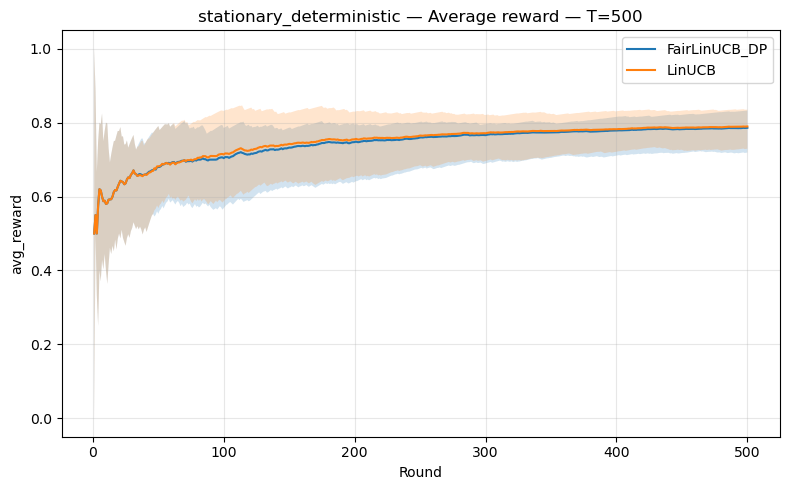

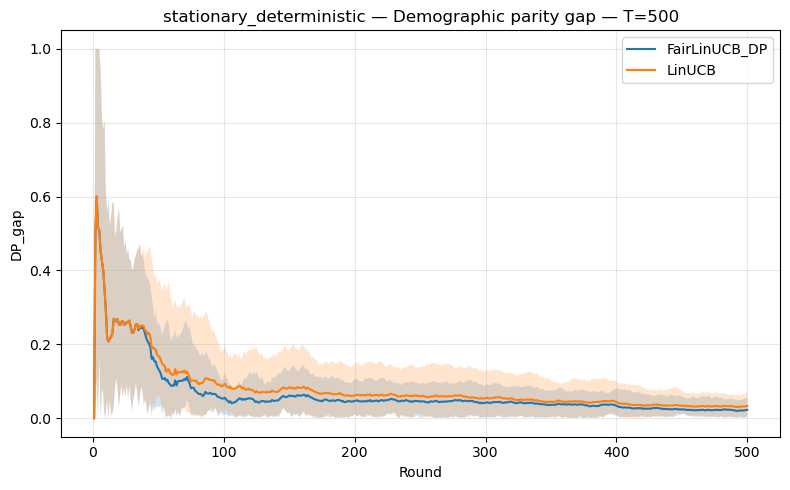

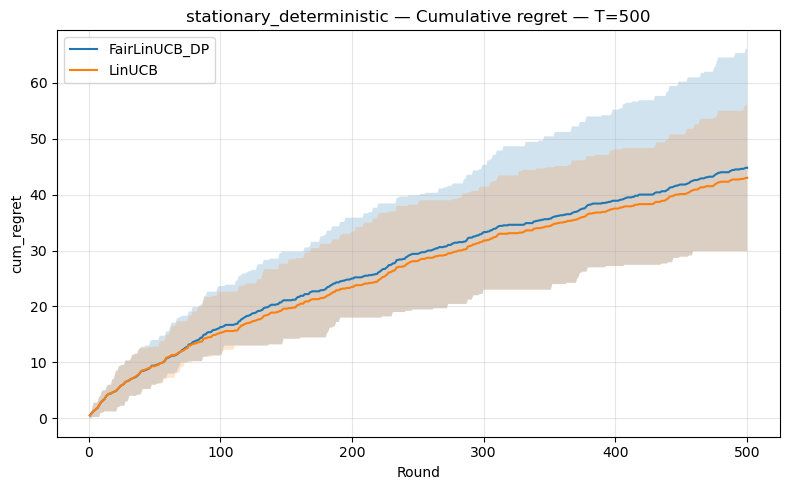

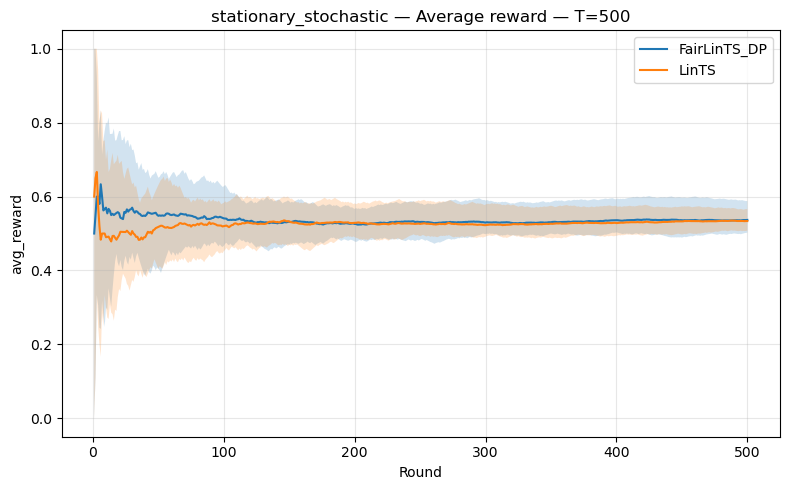

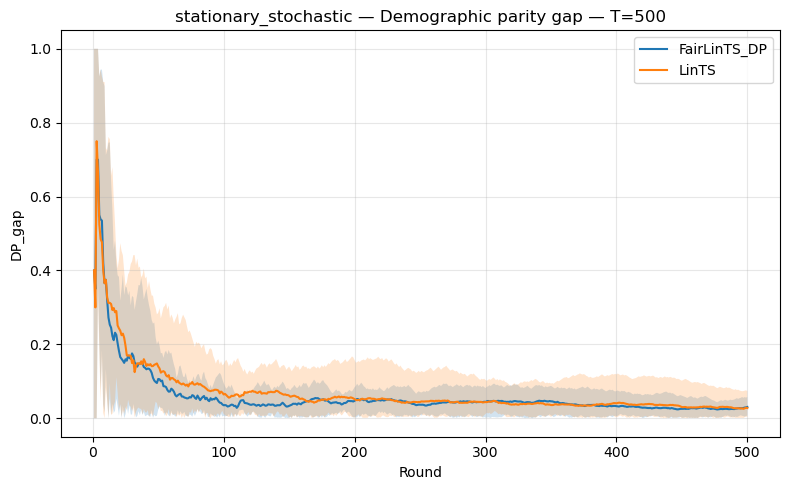

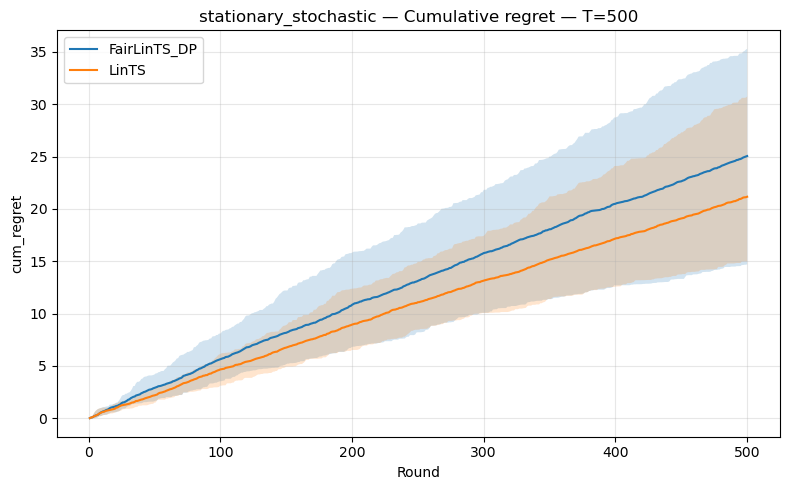

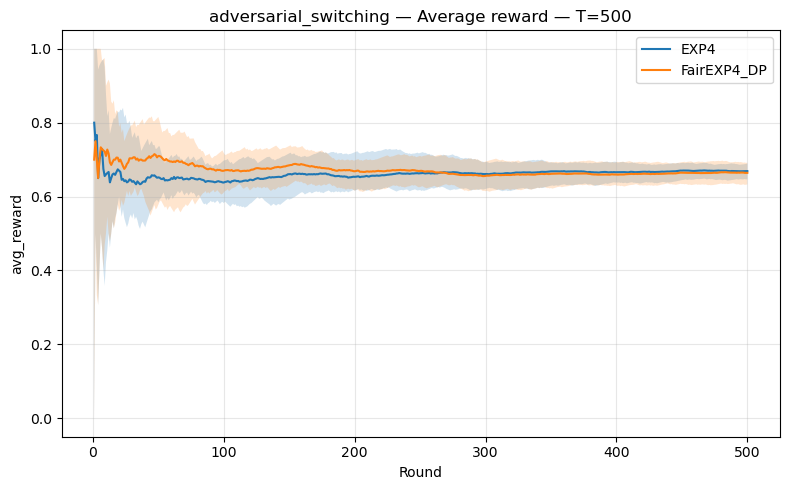

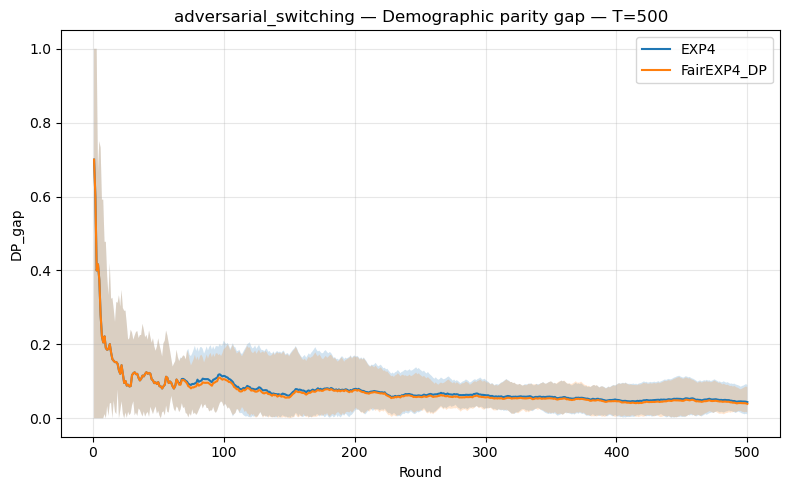

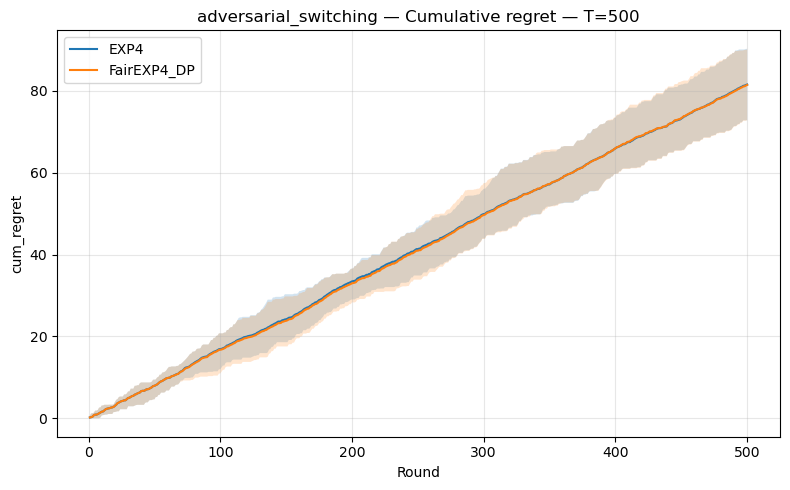

Saved temporal figures to: results\full\synthetic_cmab_regime_matched\full


In [8]:
POLICIES_BY_REGIME = {
    "stationary_deterministic": ["LinUCB", "FairLinUCB_DP"],
    "stationary_stochastic": ["LinTS", "FairLinTS_DP"],
    "adversarial_switching": ["EXP4", "FairEXP4_DP"],
}

METRICS_TO_PLOT = [
    ("avg_reward", "Average reward"),
    ("DP_gap", "Demographic parity gap"),
    ("cum_regret", "Cumulative regret"),
]

for regime, policies in POLICIES_BY_REGIME.items():
    for metric, label in METRICS_TO_PLOT:
        fig, ax = plt.subplots(figsize=(8, 5))
        plot_synth_temporal_metric(
            temporal_ci,
            regime=regime,
            T=FINAL_T,
            metric=metric,
            policies=policies,
            ax=ax,
            title=f"{regime} — {label} — T={FINAL_T}",
        )
        plt.tight_layout()
        out_path = RUN_DIR / f"temporal_{regime}_{metric}_T{FINAL_T}.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        plt.show()

print("Saved temporal figures to:", RUN_DIR)

### Compact side-by-side figure

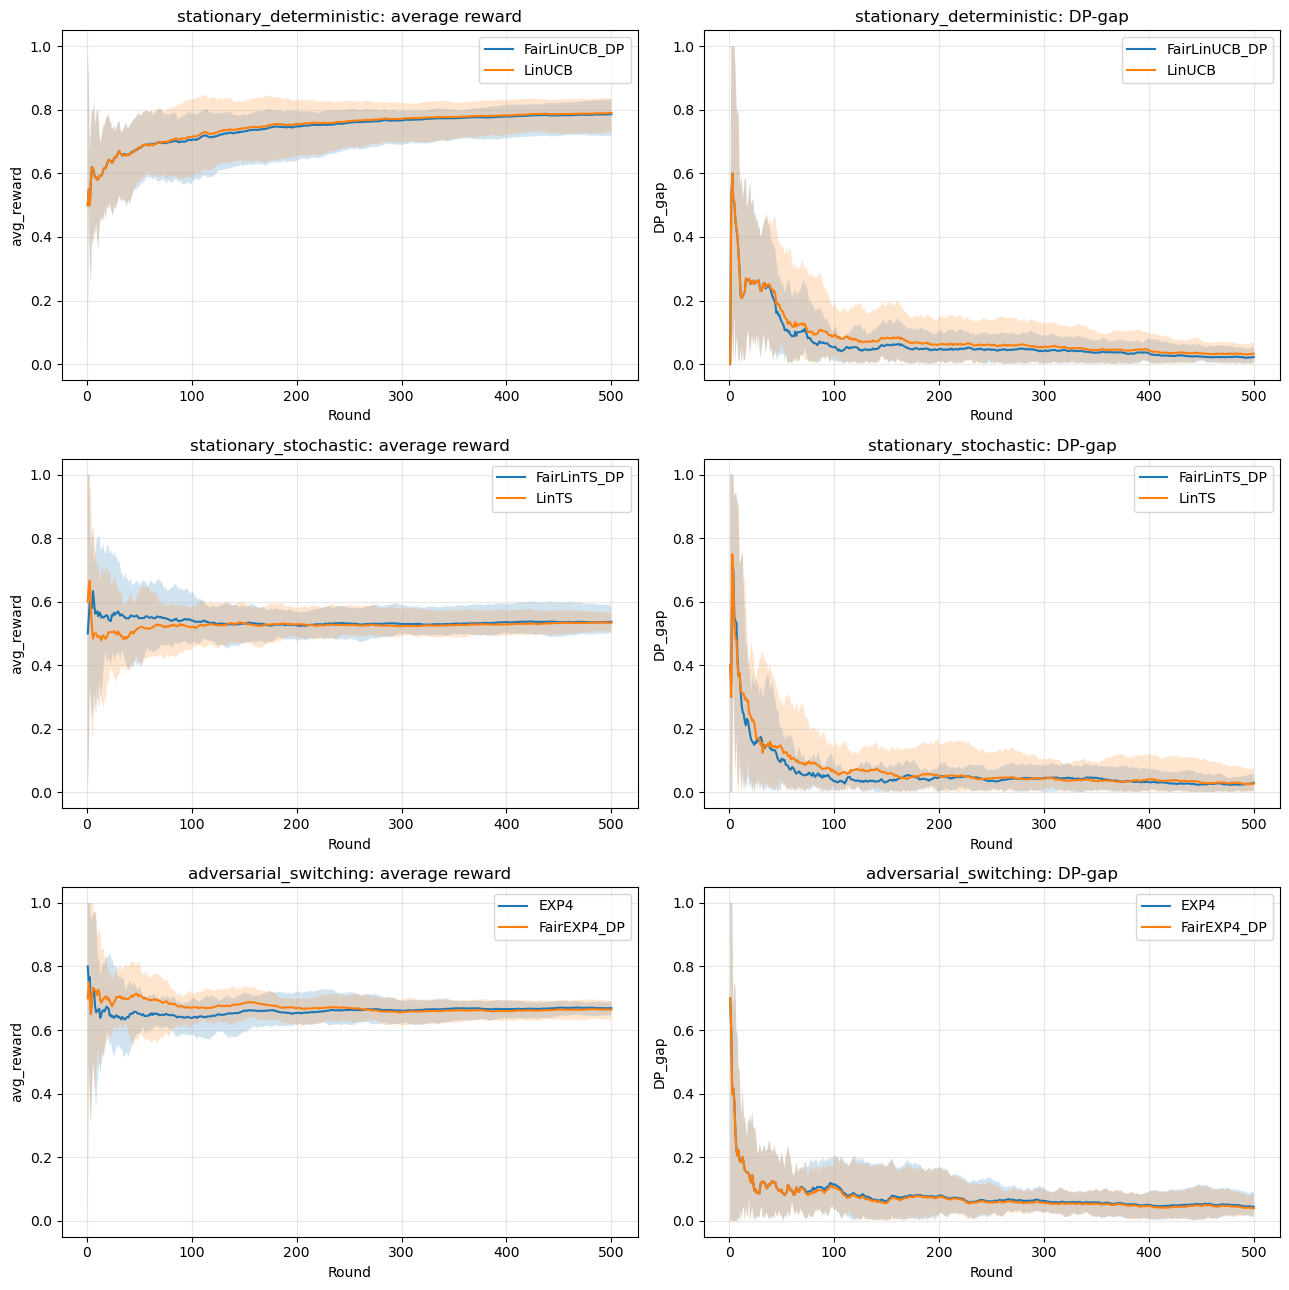

Saved: results\full\synthetic_cmab_regime_matched\full\synthetic_regime_matched_reward_dp_T500.png


In [9]:
fig, axes = plt.subplots(3, 2, figsize=(13, 13), sharex=False)

for row_idx, (regime, policies) in enumerate(POLICIES_BY_REGIME.items()):
    plot_synth_temporal_metric(
        temporal_ci,
        regime=regime,
        T=FINAL_T,
        metric="avg_reward",
        policies=policies,
        ax=axes[row_idx, 0],
        title=f"{regime}: average reward",
    )
    plot_synth_temporal_metric(
        temporal_ci,
        regime=regime,
        T=FINAL_T,
        metric="DP_gap",
        policies=policies,
        ax=axes[row_idx, 1],
        title=f"{regime}: DP-gap",
    )

plt.tight_layout()
combined_path = RUN_DIR / f"synthetic_regime_matched_reward_dp_T{FINAL_T}.png"
plt.savefig(combined_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", combined_path)

### Statistical comparisons

Because each regime compares only two methods, Wilcoxon signed-rank tests are the most relevant. Friedman tests are not informative for two-method comparisons, but "compare_methods" will still return pairwise Wilcoxon results.


In [10]:
STATS_METRICS = [
    ("avg_reward", False),
    ("cumulative_regret", True),
    ("DP_gap", True),
    ("EO_gap", True),
    ("UtilityGap", True),
]

stats_outputs = {}

for metric, lower_is_better in STATS_METRICS:
    _, wilcoxon_df = compare_methods(
        perseed,
        value_col=metric,
        method_col="policy",
        seed_col="seed",
        group_cols=["regime", "T"],
        lower_is_better=lower_is_better,
    )
    stats_outputs[metric] = wilcoxon_df
    out_path = RUN_DIR / f"wilcoxon_{metric}.csv"
    wilcoxon_df.to_csv(out_path, index=False)
    print(f"Saved {metric} tests to:", out_path)
    display(wilcoxon_df.head())



Saved avg_reward tests to: results\full\synthetic_cmab_regime_matched\full\wilcoxon_avg_reward.csv


,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,adversarial_switching,50,avg_reward,EXP4,FairEXP4_DP,10,0.706,0.6880,0.0180,17.0,0.578125,EXP4,0.578125
1,adversarial_switching,100,avg_reward,EXP4,FairEXP4_DP,10,0.649,0.6690,-0.0200,12.5,0.134766,FairEXP4_DP,0.134766
2,adversarial_switching,250,avg_reward,EXP4,FairEXP4_DP,10,0.680,0.6748,0.0052,21.5,0.576172,EXP4,0.576172
3,adversarial_switching,500,avg_reward,EXP4,FairEXP4_DP,10,0.669,0.6642,0.0048,23.5,0.718750,EXP4,0.718750
4,stationary_deterministic,50,avg_reward,FairLinUCB_DP,LinUCB,10,0.680,0.6820,-0.0020,7.0,1.000000,LinUCB,1.000000


Saved cumulative_regret tests to: results\full\synthetic_cmab_regime_matched\full\wilcoxon_cumulative_regret.csv


,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,adversarial_switching,50,cumulative_regret,EXP4,FairEXP4_DP,10,7.533612,7.541278,-0.007666,1.0,1.000000,EXP4,1.000000
1,adversarial_switching,100,cumulative_regret,EXP4,FairEXP4_DP,10,16.484174,16.426801,0.057373,9.0,0.843750,FairEXP4_DP,0.843750
2,adversarial_switching,250,cumulative_regret,EXP4,FairEXP4_DP,10,40.789504,40.895851,-0.106347,11.0,0.687500,EXP4,0.687500
3,adversarial_switching,500,cumulative_regret,EXP4,FairEXP4_DP,10,81.562599,81.463191,0.099408,16.0,0.496094,FairEXP4_DP,0.496094
4,stationary_deterministic,50,cumulative_regret,FairLinUCB_DP,LinUCB,10,9.400000,9.300000,0.100000,6.5,1.000000,LinUCB,1.000000


Saved DP_gap tests to: results\full\synthetic_cmab_regime_matched\full\wilcoxon_DP_gap.csv


,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,adversarial_switching,50,DP_gap,EXP4,FairEXP4_DP,10,0.095649,0.095517,0.000132,1.0,1.000000,FairEXP4_DP,1.000000
1,adversarial_switching,100,DP_gap,EXP4,FairEXP4_DP,10,0.099877,0.096648,0.003230,6.0,0.812500,FairEXP4_DP,0.812500
2,adversarial_switching,250,DP_gap,EXP4,FairEXP4_DP,10,0.055412,0.054919,0.000493,8.0,0.687500,FairEXP4_DP,0.687500
3,adversarial_switching,500,DP_gap,EXP4,FairEXP4_DP,10,0.043744,0.039007,0.004737,6.0,0.054688,FairEXP4_DP,0.054688
4,stationary_deterministic,50,DP_gap,FairLinUCB_DP,LinUCB,10,0.134421,0.168809,-0.034388,0.0,0.062500,FairLinUCB_DP,0.062500


Saved EO_gap tests to: results\full\synthetic_cmab_regime_matched\full\wilcoxon_EO_gap.csv


,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,adversarial_switching,50,EO_gap,EXP4,FairEXP4_DP,10,0.095649,0.095517,0.000132,1.0,1.000000,FairEXP4_DP,1.000000
1,adversarial_switching,100,EO_gap,EXP4,FairEXP4_DP,10,0.138092,0.140871,-0.002779,6.0,0.750000,EXP4,0.750000
2,adversarial_switching,250,EO_gap,EXP4,FairEXP4_DP,10,0.117310,0.113520,0.003790,0.0,0.250000,FairEXP4_DP,0.250000
3,adversarial_switching,500,EO_gap,EXP4,FairEXP4_DP,10,0.084312,0.075558,0.008754,6.0,0.109375,FairEXP4_DP,0.109375
4,stationary_deterministic,50,EO_gap,FairLinUCB_DP,LinUCB,10,0.259990,0.300034,-0.040043,0.0,0.125000,FairLinUCB_DP,0.125000


Saved UtilityGap tests to: results\full\synthetic_cmab_regime_matched\full\wilcoxon_UtilityGap.csv


,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm
0,adversarial_switching,50,UtilityGap,EXP4,FairEXP4_DP,10,0.078865,0.087087,-0.008222,23.0,0.695312,EXP4,0.695312
1,adversarial_switching,100,UtilityGap,EXP4,FairEXP4_DP,10,0.083302,0.064768,0.018534,20.0,0.492188,FairEXP4_DP,0.492188
2,adversarial_switching,250,UtilityGap,EXP4,FairEXP4_DP,10,0.036617,0.058997,-0.022380,12.0,0.250000,EXP4,0.250000
3,adversarial_switching,500,UtilityGap,EXP4,FairEXP4_DP,10,0.028785,0.027384,0.001401,24.0,0.769531,FairEXP4_DP,0.769531
4,stationary_deterministic,50,UtilityGap,FairLinUCB_DP,LinUCB,10,0.095199,0.087390,0.007809,4.0,0.437500,LinUCB,0.437500


### Main Wilcoxon table at final horizon

In [11]:
final_stats = []

for metric, df_stat in stats_outputs.items():
    if df_stat.empty:
        continue
    sub = df_stat[df_stat["T"] == FINAL_T].copy()
    sub["metric"] = metric
    final_stats.append(sub)

if final_stats:
    final_stats_df = pd.concat(final_stats, ignore_index=True)
    display(final_stats_df)
    final_stats_df.to_csv(RUN_DIR / f"wilcoxon_final_T{FINAL_T}.csv", index=False)
else:
    final_stats_df = pd.DataFrame()
    print("No final-horizon statistics available.")

,regime,T,value_col,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,statistic,p_raw,winner,p_holm,metric
0,adversarial_switching,500,avg_reward,EXP4,FairEXP4_DP,10,0.669000,0.664200,0.004800,23.5,0.718750,EXP4,0.718750,avg_reward
1,stationary_deterministic,500,avg_reward,FairLinUCB_DP,LinUCB,10,0.786200,0.789800,-0.003600,10.0,1.000000,LinUCB,1.000000,avg_reward
2,stationary_stochastic,500,avg_reward,FairLinTS_DP,LinTS,10,0.536800,0.533800,0.003000,25.0,0.845703,FairLinTS_DP,0.845703,avg_reward
3,adversarial_switching,500,cumulative_regret,EXP4,FairEXP4_DP,10,81.562599,81.463191,0.099408,16.0,0.496094,FairEXP4_DP,0.496094,cumulative_regret
4,stationary_deterministic,500,cumulative_regret,FairLinUCB_DP,LinUCB,10,44.800000,43.000000,1.800000,10.0,0.937500,LinUCB,0.937500,cumulative_regret
5,stationary_stochastic,500,cumulative_regret,FairLinTS_DP,LinTS,10,25.056405,21.166465,3.889940,6.0,0.027344,LinTS,0.027344,cumulative_regret
6,adversarial_switching,500,DP_gap,EXP4,FairEXP4_DP,10,0.043744,0.039007,0.004737,6.0,0.054688,FairEXP4_DP,0.054688,DP_gap
7,stationary_deterministic,500,DP_gap,FairLinUCB_DP,LinUCB,10,0.022717,0.033089,-0.010372,4.0,0.109375,FairLinUCB_DP,0.109375,DP_gap
8,stationary_stochastic,500,DP_gap,FairLinTS_DP,LinTS,10,0.030537,0.027720,0.002818,20.0,0.820312,LinTS,0.820312,DP_gap
9,adversarial_switching,500,EO_gap,EXP4,FairEXP4_DP,10,0.084312,0.075558,0.008754,6.0,0.109375,FairEXP4_DP,0.109375,EO_gap


### Conclusion

In this notebook, we evaluated fairness-aware contextual bandit methods under three synthetic regimes using a regime-matched comparison setup. This design allows each policy family to be tested in conditions aligned with its modeling assumptions, which improves interpretability and avoids misleading cross-regime comparisons.

Overall, the results indicate a consistent utility-fairness trade-off: the fair variants generally reduce group-level disparity metrics, while sometimes incurring a moderate performance cost in reward or regret. The size of this trade-off is regime-dependent, with stronger differences appearing in more challenging settings such as adversarial switching.

From a methodological perspective, the temporal confidence interval analysis and the per-seed aggregation provide a robust view of behavior over time and across random initializations. This supports the reliability of the observed trends and helps separate systematic effects from seed-level variance.

These findings support the main thesis claim that fairness interventions in online decision-making can be effective, but their practical value depends on the operating regime and the acceptable utility loss in the target application. Future work should extend this benchmark with richer non-stationary dynamics and additional fairness notions to further evaluate robustness beyond the current synthetic setup.